In [27]:
import pandas as pd
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
from pathlib import Path
import spacy
import re
from tqdm import tqdm
import matplotlib.dates as mdates
import ast


# Add the parent directory to sys.path so src can be imported
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import src.utils as utils

# Cargar los datos

In [8]:
file_path2 = r"..\data\processed\corpus_cleaned.xlsx"
corpus_cleaned = pd.read_excel(file_path2, engine='openpyxl')

chunks_df = pd.read_parquet(r"..\data\processed\chunks.parquet")

In [6]:
# Leer chunks, está en excel
chunks_etiquetados = pd.read_excel("../data/results/chunks_etiquetados_binario.xlsx")
chunks_etiquetados.head()

,chunk_id,id_doc,texto_chunk,Ciencias_ambientales_ingenieria,Ciencias_espacio,Ciencias_fisicas,Ciencias_Geografia_oceanografia,Ciencias_medicas,Ciencias_metereologia,Ciencias_naturales,...,Ciencias_tierra,Ciencia_Administracion_ciencia_investigacion,Ciencia_biologia,Ciencia_enfoque_cientifico,Ciencia_hidrologia,Ciencia_matematicas_estadistica,Ciencia_patologia,Ciencia_recursos_naturales,categorias_detectadas,etiqueta_ciencia
0,0,1,"La Coalición Colombia Partido Alianza Verde, P...",0.411230,0.368818,0.363447,0.354240,0.378154,0.343397,0.387251,...,0.392998,0.423331,0.337017,0.352550,0.328395,0.394268,0.393815,0.389038,"[('ninguna', 0)]",0
1,1,1,"al mismo tiempo lo exponen, en ciertas ocasion...",0.331604,0.304309,0.346682,0.315253,0.344347,0.323262,0.344607,...,0.318409,0.378231,0.317467,0.368125,0.306375,0.381964,0.337864,0.306510,"[('ninguna', 0)]",0
2,2,1,los acuerdos con las Farc. Anunció que no prom...,0.356805,0.311163,0.303825,0.287517,0.329738,0.290927,0.332603,...,0.292858,0.405040,0.291387,0.322885,0.297822,0.338846,0.294842,0.318955,"[('ninguna', 0)]",0
3,3,1,moratoria en la explotación tipo fracking. Y f...,0.435032,0.397881,0.372960,0.368983,0.415538,0.357000,0.410173,...,0.392092,0.445708,0.370653,0.367256,0.341832,0.404120,0.375238,0.397525,"[('ninguna', 0)]",0
4,0,2,Las interpretaciones de la historia sirven com...,0.352643,0.367811,0.375234,0.357391,0.368184,0.347770,0.392265,...,0.368177,0.428733,0.353389,0.405911,0.371109,0.412153,0.397781,0.339795,"[('ninguna', 0)]",0


In [7]:
chunks_ciencias = chunks_etiquetados[chunks_etiquetados["etiqueta_ciencia"] == 1]

# columnas que contienen los scores de las diferentes ciencias
cols = [c for c in chunks_ciencias.columns
    if c.startswith("Ciencias_") or c.startswith("Ciencia_")]

# obtener sólo los chunks cuyo máximo absoluto cae en
# “Ciencia_Administracion_ciencia_investigacion”
chunks_ciencias_admin = chunks_ciencias[
    chunks_ciencias[cols].idxmax(axis=1)
    == "Ciencia_Administracion_ciencia_investigacion"
]

chunks_ciencias_admin.shape, chunks_ciencias_admin.head()

((3195, 22),
      chunk_id  id_doc                                        texto_chunk  \
 43          1      10  estabilidad, visión de futuro y apertura al co...   
 44          2      10  que se escoja la fórmula presidencial con estr...   
 46          0      11  El método es sencillo. Primero tensar un poco ...   
 72          1      15  creando poderosos cuerpos armados paralelos qu...   
 124         0      27  ¿Qué hace que miembros de sociedades divididas...   
 
      Ciencias_ambientales_ingenieria  Ciencias_espacio  Ciencias_fisicas  \
 43                          0.461249          0.396793          0.401036   
 44                          0.432813          0.389536          0.411760   
 46                          0.422972          0.398423          0.410561   
 72                          0.417950          0.416532          0.439040   
 124                         0.378887          0.372949          0.395535   
 
      Ciencias_Geografia_oceanografia  Ciencias_medicas  Ci

In [11]:
chunks_ciencias_admin_merged = chunks_ciencias_admin.merge(
    chunks_df[['id_doc', 'chunk_id', 'titulo_doc', 'autor_doc', 'fecha_doc', 'diario_doc']],
    on=['id_doc', 'chunk_id'],
    how='left'
)

chunks_ciencias_admin_merged

,chunk_id,id_doc,texto_chunk,Ciencias_ambientales_ingenieria,Ciencias_espacio,Ciencias_fisicas,Ciencias_Geografia_oceanografia,Ciencias_medicas,Ciencias_metereologia,Ciencias_naturales,...,Ciencia_hidrologia,Ciencia_matematicas_estadistica,Ciencia_patologia,Ciencia_recursos_naturales,categorias_detectadas,etiqueta_ciencia,titulo_doc,autor_doc,fecha_doc,diario_doc
0,1,10,"estabilidad, visión de futuro y apertura al co...",0.461249,0.396793,0.401036,0.404579,0.445807,0.404155,0.421193,...,0.398157,0.456001,0.427080,0.436823,"[('Ciencias_polucion_catastrofes_seguridad', 0...",1,"Clara, Humberto, Gustavo: la esperanza",Luis I. Sandoval M.,2018-01-01,El Espectador
1,2,10,que se escoja la fórmula presidencial con estr...,0.432813,0.389536,0.411760,0.408603,0.419465,0.404222,0.437402,...,0.405430,0.466137,0.408754,0.426791,[('Ciencia_Administracion_ciencia_investigacio...,1,"Clara, Humberto, Gustavo: la esperanza",Luis I. Sandoval M.,2018-01-01,El Espectador
2,0,11,El método es sencillo. Primero tensar un poco ...,0.422972,0.398423,0.410561,0.395789,0.412290,0.392898,0.435677,...,0.403404,0.444334,0.411773,0.415889,[('Ciencia_Administracion_ciencia_investigacio...,1,Elecciones típicas,Pascual Gaviria,2018-01-02,El Espectador
3,1,15,creando poderosos cuerpos armados paralelos qu...,0.417950,0.416532,0.439040,0.376707,0.450884,0.383261,0.438462,...,0.385595,0.418124,0.449374,0.385799,[('Ciencia_Administracion_ciencia_investigacio...,1,Autócratas,Marcos Peckel,2018-01-02,El Espectador
4,0,27,¿Qué hace que miembros de sociedades divididas...,0.378887,0.372949,0.395535,0.357060,0.384036,0.360637,0.391136,...,0.360454,0.421877,0.367899,0.327612,[('Ciencia_Administracion_ciencia_investigacio...,1,Deliberación en la división,Vivian Newman,2018-01-05,El Espectador
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3190,2,13670,de mercado para proyectos semejantes donde los...,0.405087,0.363564,0.348389,0.319041,0.377561,0.359642,0.365868,...,0.387962,0.391810,0.359039,0.356897,[('Ciencia_Administracion_ciencia_investigacio...,1,"Alcalde: de las carreras, solo queda el cansancio",Clara López Obregón,2019-06-04,Semana
3191,3,13670,"ejecución. Por si fuera poco, durante el escas...",0.434345,0.389919,0.386449,0.331937,0.385795,0.381422,0.389492,...,0.379387,0.397558,0.401377,0.370059,[('Ciencia_Administracion_ciencia_investigacio...,1,"Alcalde: de las carreras, solo queda el cansancio",Clara López Obregón,2019-06-04,Semana
3192,6,13671,empresas y juntos diseñaron el mejor marco pos...,0.409905,0.352519,0.373904,0.322059,0.379840,0.333315,0.378122,...,0.351471,0.377240,0.351933,0.359391,[('Ciencia_Administracion_ciencia_investigacio...,1,La era de la micromovilidad,Gonzalo Araújo Muñoz,2019-06-03,Semana
3193,4,13672,negociaciones. Tantas cosas por resolver y en ...,0.431984,0.397463,0.385541,0.378124,0.411482,0.375245,0.432138,...,0.397724,0.412351,0.419973,0.379041,[('Ciencia_Administracion_ciencia_investigacio...,1,Es hora de salir de la trampa,Gonzalo Sánchez,2019-06-04,Semana


C:\Users\karen\AppData\Local\Temp\ipykernel_15344\170360594.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  total_mensual = corpus_cleaned.groupby(pd.Grouper(key='Fecha', freq='M')).size()
C:\Users\karen\AppData\Local\Temp\ipykernel_15344\170360594.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  science_mensual = chunks_ciencias_admin_merged.groupby(pd.Grouper(key='fecha_doc', freq='M'))['id_doc'].nunique()


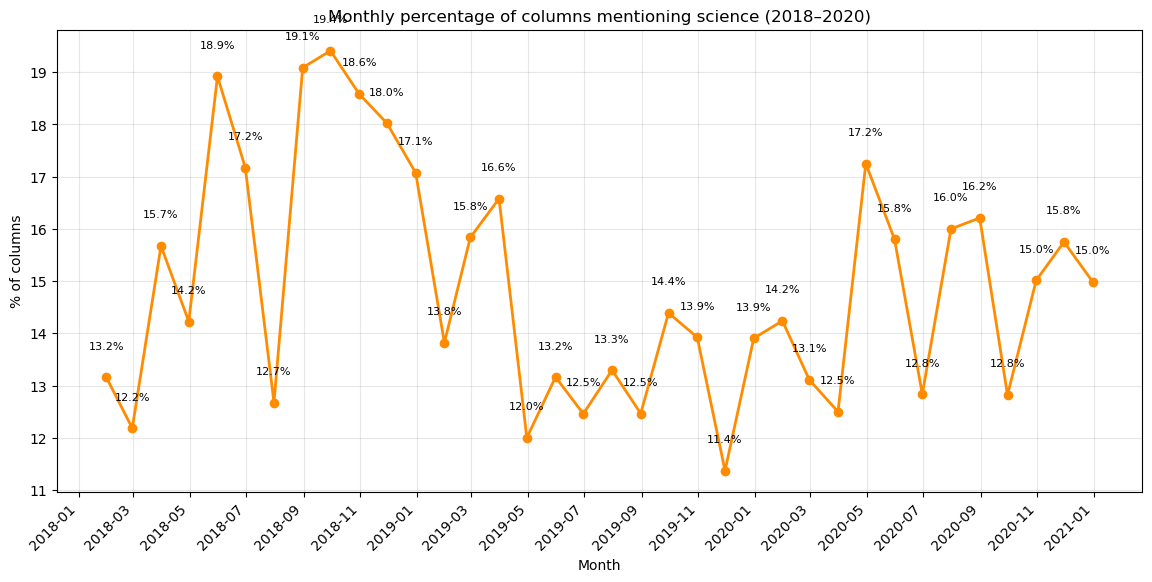

In [14]:
# Calculate total articles per month
total_mensual = corpus_cleaned.groupby(pd.Grouper(key='Fecha', freq='M')).size()

# Calculate science articles per month (unique id_doc with science chunks)
science_mensual = chunks_ciencias_admin_merged.groupby(pd.Grouper(key='fecha_doc', freq='M'))['id_doc'].nunique()

# Merge to get a DataFrame with both counts
mensual = pd.DataFrame({'total': total_mensual, 'science': science_mensual}).fillna(0)

# Calculate percentage
mensual['porcentaje'] = (mensual['science'] / mensual['total']) * 100

# Plot the graph
plt.figure(figsize=(14,6))
plt.plot(mensual.index, mensual["porcentaje"], marker='o', linestyle='-', color='darkorange', linewidth=2)
plt.title("Monthly percentage of columns mentioning science (2018–2020)")
plt.ylabel("% of columns")
plt.xlabel("Month")
plt.grid(alpha=0.3)
ax = plt.gca()
# Formato de fechas en el eje x
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45, ha='right')

# Añadir etiquetas con el porcentaje en cada punto
for x, y in zip(mensual.index, mensual["porcentaje"]):
    if not np.isnan(y):
        plt.text(x, y + 0.5, f"{y:.1f}%", ha="center", va="bottom", fontsize=8)

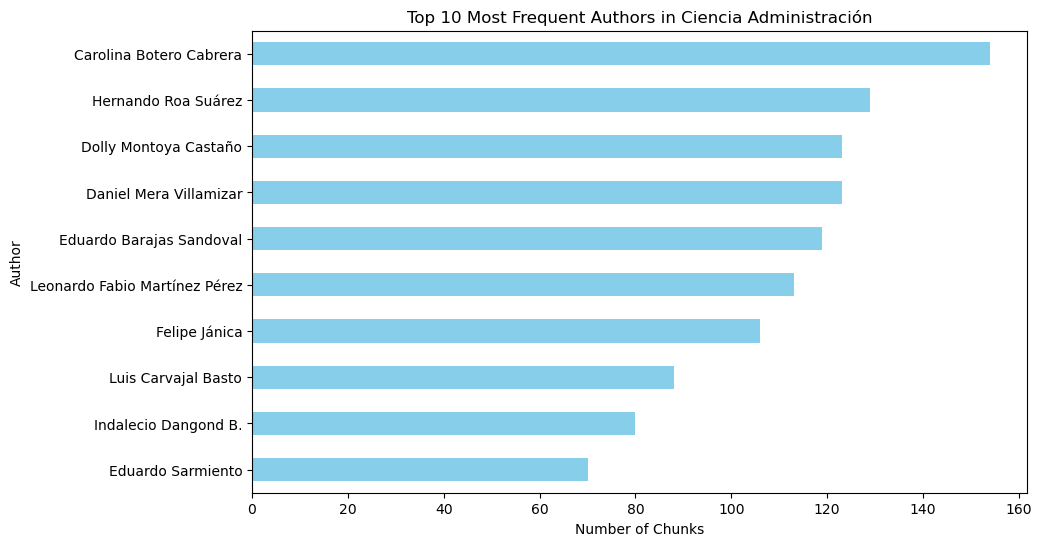

In [15]:
# Count the frequency of each author in chunks_ciencias_admin_merged
author_counts = chunks_ciencias_admin_merged['autor_doc'].value_counts().head(10)  # Top 10 authors

# Plot horizontal bar chart
plt.figure(figsize=(10, 6))
author_counts.plot(kind='barh', color='skyblue')
plt.title('Top 10 Most Frequent Authors in Ciencia Administración')
plt.xlabel('Number of Chunks')
plt.ylabel('Author')
plt.gca().invert_yaxis()  # Invert y-axis to have the highest at the top
plt.show()

# Nube de palabras

In [16]:
nlp = spacy.load("es_core_news_sm")
# Stopwords en español
STOP_WORDS = nlp.Defaults.stop_words

In [17]:
chunks_ciencias_admin_merged.columns

Index(['chunk_id', 'id_doc', 'texto_chunk', 'Ciencias_ambientales_ingenieria',
       'Ciencias_espacio', 'Ciencias_fisicas',
       'Ciencias_Geografia_oceanografia', 'Ciencias_medicas',
       'Ciencias_metereologia', 'Ciencias_naturales',
       'Ciencias_polucion_catastrofes_seguridad', 'Ciencias_quimicas',
       'Ciencias_tierra', 'Ciencia_Administracion_ciencia_investigacion',
       'Ciencia_biologia', 'Ciencia_enfoque_cientifico', 'Ciencia_hidrologia',
       'Ciencia_matematicas_estadistica', 'Ciencia_patologia',
       'Ciencia_recursos_naturales', 'categorias_detectadas',
       'etiqueta_ciencia', 'titulo_doc', 'autor_doc', 'fecha_doc',
       'diario_doc'],
      dtype='object')

In [18]:
texto_ciencia = " ".join(chunks_ciencias_admin_merged["texto_chunk"].tolist())
texto_ciencia = texto_ciencia.lower()

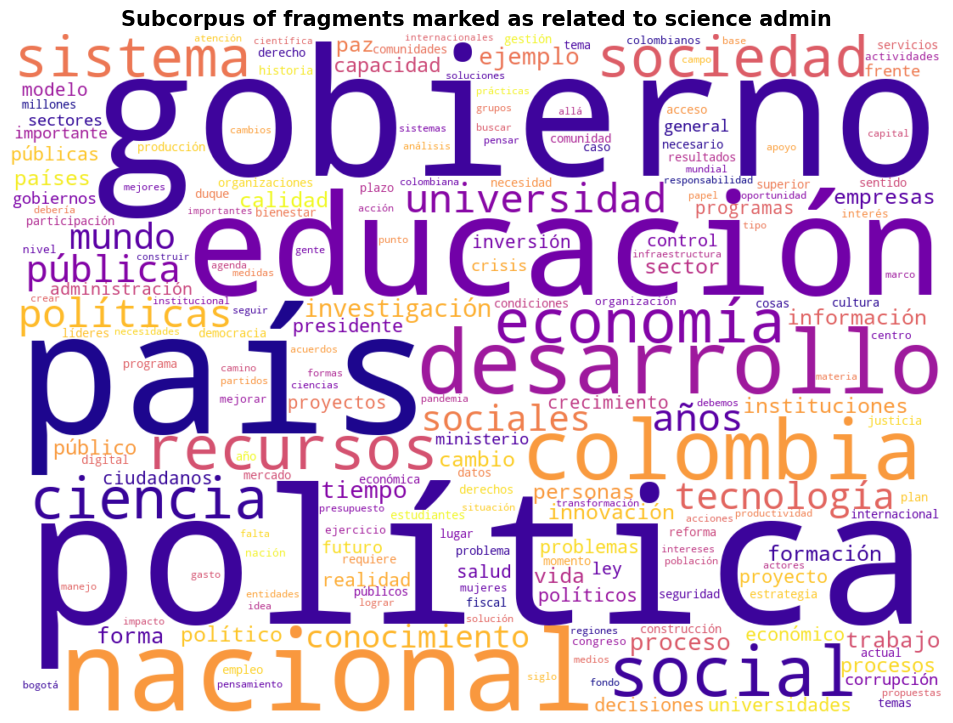

In [22]:
wc = WordCloud(
        width=1100, height=800,
        background_color='white',
        max_words=200,
        stopwords=STOP_WORDS,
        prefer_horizontal=1.0,  # Todas horizontales
        relative_scaling=0.9,   
        collocations=False,
        random_state=42,
        min_font_size=10,
        #max_font_size=150,
        colormap='plasma',
        normalize_plurals = False
    ).generate(texto_ciencia)

 # Crear la visualización
plt.figure(figsize=(10, 8))
plt.imshow(wc, interpolation='bilinear')
plt.title("Subcorpus of fragments marked as related to science admin", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.axis('off')
#plt.savefig("../reports/articulo_revista/figures/nube_ciencia_admin.png", dpi=300)
plt.show()

# Análisis NER

In [24]:
ner_general = pd.read_parquet(r"..\data\results\general_ner.parquet")
ner_general

,chunk_id,id_doc,texto_chunk,categorias_detectadas,etiqueta_ciencia,entidades
0,0,1,"La Coalición Colombia Partido Alianza Verde, P...","[('ninguna', 0)]",0,"[[ORG, Coalición Colombia Partido Alianza Verd..."
1,1,1,"al mismo tiempo lo exponen, en ciertas ocasion...","[('ninguna', 0)]",0,"[[ORG, RCN Radio], [PER, Jorge Enrique Robledo..."
2,2,1,los acuerdos con las Farc. Anunció que no prom...,"[('ninguna', 0)]",0,"[[ORG, Far], [MISC, Dian], [PER, Fajardo]]"
3,3,1,moratoria en la explotación tipo fracking. Y f...,"[('ninguna', 0)]",0,"[[PER, Fajardo], [ORG, Pontificia Universidad ..."
4,0,2,Las interpretaciones de la historia sirven com...,"[('ninguna', 0)]",0,"[[MISC, G], [LOC, Balcanes]]"
...,...,...,...,...,...,...
62646,7,13676,"así, encuentra el 90 del alimento que guardó. ...","[('ninguna', 0)]",0,"[[PER, Piaget], [PER, Rodolfo Llinás]]"
62647,8,13676,capacidad de predecir un evento futuro. Por lo...,"[('Ciencias_naturales', 0.48311546444892883)]",1,"[[LOC, Escandinavia]]"
62648,9,13676,similar. Se ha encontrado que éstos le roban l...,"[('ninguna', 0)]",0,[]
62649,10,13676,está siendo parcialmente validada con experime...,"[('Ciencias_naturales', 0.5003376007080078)]",1,"[[PER, Brecht]]"


In [25]:
ner_general['entidades'][10]

array([array(['PER', 'Filipo'], dtype=object),
       array(['PER', 'Alejandro Magno'], dtype=object),
       array(['PER', 'Aristóteles'], dtype=object),
       array(['ORG', 'FYROM'], dtype=object),
       array(['PER', 'Zoran Zaev'], dtype=object),
       array(['LOC', 'Tesaloniki'], dtype=object),
       array(['PER', 'Yannis Butaris'], dtype=object),
       array(['LOC', 'Krusevo'], dtype=object),
       array(['PER', 'Zaev'], dtype=object),
       array(['LOC', 'Aeropuerto Macedonia'], dtype=object),
       array(['LOC', 'Tesaloniki'], dtype=object),
       array(['LOC', 'Macedonia'], dtype=object),
       array(['PER', 'Butaris'], dtype=object)], dtype=object)

In [26]:
# Función para extraer entidades
def extract_entities(entities_array):
    """Extrae las entidades del formato array"""
    entities_list = []
    
    if isinstance(entities_array, str):
        try:
            entities_array = ast.literal_eval(entities_array)
        except:
            return entities_list
    
    if hasattr(entities_array, '__iter__'):
        for item in entities_array:
            if isinstance(item, (list, tuple, np.ndarray)) and len(item) >= 2:
                entity_type = str(item[0])
                entity_name = str(item[1])
                entities_list.append((entity_type, entity_name))
    
    return entities_list

In [29]:
# --- 1. Filtrar ner_general para quedarnos solo con los chunks de ciencia admin ---

ner_admin = ner_general.merge(
    chunks_ciencias_admin_merged[['id_doc', 'chunk_id']].drop_duplicates(),
    on=['id_doc', 'chunk_id'],
    how='inner'
).copy()

print(f"Chunks totales en general_ner:    {len(ner_general)}")
print(f"Chunks de ciencia administración: {len(ner_admin)}")

Chunks totales en general_ner:    62651
Chunks de ciencia administración: 3195


In [30]:
# --- 2. Extraer entidades del subcorpus de ciencia administración ---

entidades_admin = []

for _, row in ner_admin.iterrows():
    entidades = extract_entities(row['entidades'])   # función ya definida en la celda anterior
    for entidad in entidades:
        entidades_admin.append({
            'chunk_id':   row['chunk_id'],
            'id_doc':     row['id_doc'],
            'tipo':       entidad[0],
            'nombre':     entidad[1],
        })

df_entidades_admin = pd.DataFrame(entidades_admin)

print(f"Total de menciones de entidades: {len(df_entidades_admin)}")
df_entidades_admin.head()

Total de menciones de entidades: 11018


,chunk_id,id_doc,tipo,nombre
0,1,10,LOC,Estado
1,2,10,LOC,Colombia
2,1,15,ORG,Olimpo
3,0,27,PER,Jürg Steiner
4,0,27,PER,María Clara Jaramillo


In [31]:
# --- 2. Extraer entidades del subcorpus de ciencia administración ---

entidades_admin = []

for _, row in ner_admin.iterrows():
    entidades = extract_entities(row['entidades'])   # función ya definida en la celda anterior
    for entidad in entidades:
        entidades_admin.append({
            'chunk_id':   row['chunk_id'],
            'id_doc':     row['id_doc'],
            'tipo':       entidad[0],
            'nombre':     entidad[1],
        })

df_entidades_admin = pd.DataFrame(entidades_admin)

print(f"Total de menciones de entidades: {len(df_entidades_admin)}")
df_entidades_admin.head()

Total de menciones de entidades: 11018


,chunk_id,id_doc,tipo,nombre
0,1,10,LOC,Estado
1,2,10,LOC,Colombia
2,1,15,ORG,Olimpo
3,0,27,PER,Jürg Steiner
4,0,27,PER,María Clara Jaramillo


In [33]:
# --- 3. Tabla de frecuencias por tipo y entidad ---

tabla_admin = (
    df_entidades_admin
    .groupby(['tipo', 'nombre'])
    .agg(
        frecuencia_total  = ('chunk_id', 'size'),
        n_docs            = ('id_doc',   'nunique'),
    )
    .reset_index()
    .sort_values('frecuencia_total', ascending=False)
    .reset_index(drop=True)
)

tabla_admin.columns = ['Tipo', 'Entidad', 'Frecuencia_Total', 'N_Docs']

print(f"Entidades únicas encontradas: {len(tabla_admin)}")
tabla_admin.head(20)

Entidades únicas encontradas: 4558


,Tipo,Entidad,Frecuencia_Total,N_Docs
0,LOC,Colombia,614,433
1,LOC,Estado,589,364
2,ORG,Gobierno,228,172
3,PER,Duque,151,111
4,LOC,Bogotá,127,88
5,ORG,Congreso,114,90
6,LOC,Estados Unidos,111,93
7,LOC,América Latina,80,61
8,ORG,Universidad,74,29
9,LOC,China,63,48


In [38]:
# Extraer entidades de ner_general completo, marcando si el chunk es de admin
admin_keys = set(zip(chunks_ciencias_admin_merged['id_doc'], chunks_ciencias_admin_merged['chunk_id']))

entidades_con_etiqueta = []

for _, row in ner_general.iterrows():
    entidades = extract_entities(row['entidades'])
    es_admin = 1 if (row['id_doc'], row['chunk_id']) in admin_keys else 0
    
    for entidad in entidades:
        entidades_con_etiqueta.append({
            'tipo':           entidad[0],
            'nombre':         entidad[1],
            'etiqueta_ciencia': row['etiqueta_ciencia'],  # ciencia general (ya en ner_general)
            'etiqueta_admin': es_admin,
        })

df_temp = pd.DataFrame(entidades_con_etiqueta)

# Calcular frecuencias
resultado = df_temp.groupby(['tipo', 'nombre']).agg(
    frecuencia_total   = ('etiqueta_ciencia', 'size'),
    frecuencia_ciencia = ('etiqueta_ciencia', lambda x: (x == 1).sum()),
    frecuencia_admin   = ('etiqueta_admin',   lambda x: (x == 1).sum()),
).reset_index()

resultado['frecuencia_no_ciencia'] = resultado['frecuencia_total'] - resultado['frecuencia_ciencia']
resultado['cociente_ciencia'] = (resultado['frecuencia_ciencia'] / resultado['frecuencia_total']).round(4)
resultado['cociente_admin']   = (resultado['frecuencia_admin']   / resultado['frecuencia_total']).round(4)

resultado = resultado[[
    'tipo', 'nombre',
    'frecuencia_total', 'frecuencia_no_ciencia',
    'frecuencia_ciencia', 'cociente_ciencia',
    'frecuencia_admin',  'cociente_admin',
]]

resultado.columns = [
    'Tipo', 'Entidad',
    'Frecuencia_Total', 'Frecuencia_No_Ciencia',
    'Frecuencia_Ciencia', 'Cociente_Ciencia',
    'Frecuencia_Admin',  'Cociente_Admin',
]

resultado = resultado.sort_values('Frecuencia_Total', ascending=False).reset_index(drop=True)

resultado.to_excel('../data/results/entidades_ciencia_admin.xlsx', index=False)

print(f"Entidades únicas encontradas: {len(resultado)}")
print(resultado.head(10))

Entidades únicas encontradas: 65026
  Tipo         Entidad  Frecuencia_Total  Frecuencia_No_Ciencia  \
0  LOC        Colombia             14815                  13443   
1  PER           Duque              6159                   5893   
2  LOC          Estado              5486                   4582   
3  LOC  Estados Unidos              4163                   3889   
4  PER           Uribe              4140                   4064   
5  LOC          Bogotá              3769                   3370   
6  PER           Trump              3252                   3084   
7  ORG        Gobierno              3105                   2780   
8  PER           Petro              2880                   2788   
9  LOC       Venezuela              2774                   2656   

   Frecuencia_Ciencia  Cociente_Ciencia  Frecuencia_Admin  Cociente_Admin  
0                1372            0.0926               614          0.0414  
1                 266            0.0432               151          0.0245 

In [39]:
resultado

,Tipo,Entidad,Frecuencia_Total,Frecuencia_No_Ciencia,Frecuencia_Ciencia,Cociente_Ciencia,Frecuencia_Admin,Cociente_Admin
0,LOC,Colombia,14815,13443,1372,0.0926,614,0.0414
1,PER,Duque,6159,5893,266,0.0432,151,0.0245
2,LOC,Estado,5486,4582,904,0.1648,589,0.1074
3,LOC,Estados Unidos,4163,3889,274,0.0658,111,0.0267
4,PER,Uribe,4140,4064,76,0.0184,33,0.0080
...,...,...,...,...,...,...,...,...
65021,ORG,##EI,1,1,0,0.0000,0,0.0000
65022,ORG,##EL,1,1,0,0.0000,0,0.0000
65023,ORG,##EM,1,0,1,1.0000,0,0.0000
65024,ORG,##ES,1,1,0,0.0000,0,0.0000


# POS-tagging

In [43]:
PATH_WORKING = r"../data/processed/"

df_verbos = pd.read_excel(PATH_WORKING + "verbos_stanza.xlsx")
df_adjetivos = pd.read_excel(PATH_WORKING + "adjetivos_stanza.xlsx")
df_sustantivos = pd.read_excel(PATH_WORKING + "sustantivos_stanza.xlsx")


In [52]:
admin_keys = set(zip(chunks_ciencias_admin_merged['id_doc'], chunks_ciencias_admin_merged['chunk_id']))

for df in [df_verbos, df_adjetivos, df_sustantivos]:
    df['etiqueta_admin'] = df.apply(
        lambda row: 1 if (row['id_doc'], row['chunk_id']) in admin_keys else 0,
        axis=1
    )

In [48]:
def asegurar_dict(x):
    if isinstance(x, dict):
        return x
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except:
            return {}
    return {}

def construir_tabla_frecuencias(
    df,
    columna_diccionarios,
    columna_ciencia="etiqueta_ciencia",
    columna_admin="etiqueta_admin"  # Nueva columna para ciencia_admin
):
    freq_total = Counter()
    freq_ciencia = Counter()
    freq_admin = Counter()  # Nuevo contador para admin

    for _, row in tqdm(df.iterrows(), total=len(df)):
        dic = asegurar_dict(row[columna_diccionarios])

        if not dic:
            continue

        freq_total.update(dic)

        if row[columna_ciencia] == 1:
            freq_ciencia.update(dic)

        if row[columna_admin] == 1:  # Nueva condición para admin
            freq_admin.update(dic)

    # construir tabla
    data = []
    for palabra, f_total in freq_total.items():
        f_ciencia = freq_ciencia.get(palabra, 0)
        proporcion = f_ciencia / f_total if f_total > 0 else 0

        f_admin = freq_admin.get(palabra, 0)  # Nueva frecuencia para admin
        proporcion_admin = f_admin / f_total if f_total > 0 else 0  # Nueva proporción para admin

        data.append({
            "palabra": palabra,
            "frecuencia_total": f_total,
            "frecuencia_ciencia": f_ciencia,
            "proporcion_ciencia": proporcion,
            "frecuencia_ciencia_admin": f_admin,  # Nueva columna
            "proporcion_ciencia_admin": proporcion_admin  # Nueva columna
        })

    df_resultado = pd.DataFrame(data)

    # protección contra DataFrame vacío
    if df_resultado.empty:
        print("Advertencia: no se generaron frecuencias.")
        return df_resultado

    return df_resultado.sort_values(
        by="frecuencia_total",
        ascending=False
    ).reset_index(drop=True)



In [53]:
tabla_verbos = construir_tabla_frecuencias(
    df_verbos,
    columna_diccionarios="verbos_lemas_frecuencias"
)

tabla_adjetivos = construir_tabla_frecuencias(
    df_adjetivos,
    columna_diccionarios="adjetivos_lemas_frecuencias"
)

tabla_sustantivos = construir_tabla_frecuencias(
    df_sustantivos,
    columna_diccionarios="sustantivos_lemas_frecuencias"
)

100%|██████████| 62651/62651 [00:17<00:00, 3495.77it/s]


In [55]:
ruta_salida = "../data/results/frecuencias_pos_global_vs_ciencia_vs_admin.xlsx"

with pd.ExcelWriter(ruta_salida) as writer:
    tabla_verbos.to_excel(
        writer,
        sheet_name="verbos",
        index=False
    )
    tabla_adjetivos.to_excel(
        writer,
        sheet_name="adjetivos",
        index=False
    )
    tabla_sustantivos.to_excel(
        writer,
        sheet_name="sustantivos",
        index=False
    )